# Filtrage

In [3]:
%run ./init.py

## Virer composante

...

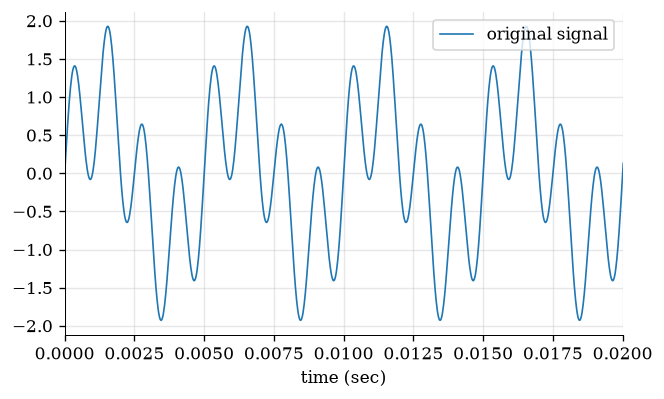

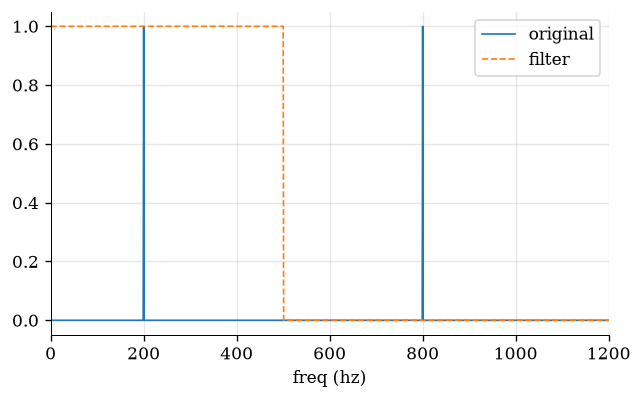

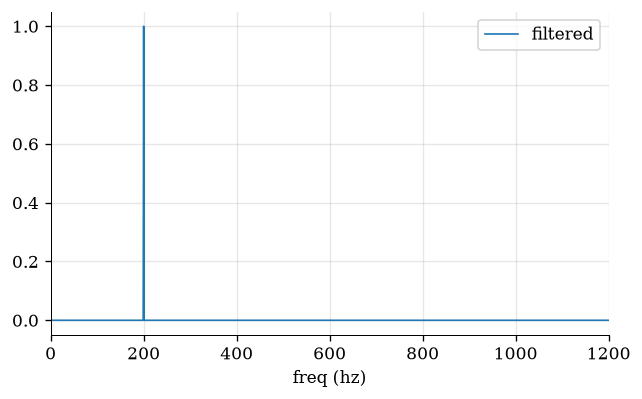

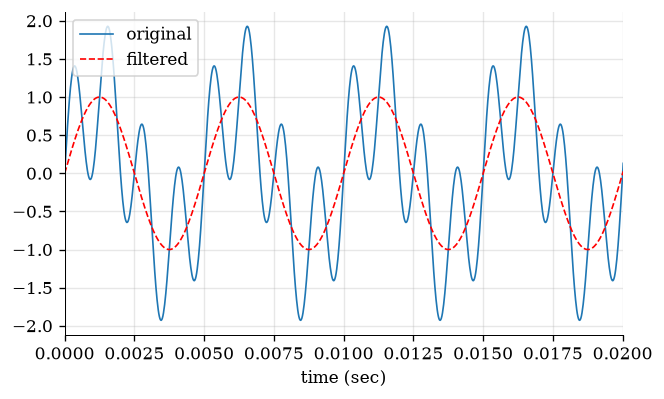

In [4]:
# init locals
f1 = 200
f2 = 800
cutoff_freq = 500

# define signals
x1, t = get_sine(f1, sampling_rate = fs)
x2, t = get_sine(f2, sampling_rate = fs)
x = x1 + x2

# play
playsound(x, fs)

# plot
plt.plot(t, x, label = 'original signal');
plt.legend(); plt.xlabel('time (sec)');
plt.xlim([0, 0.02]); plt.show();

# fft
n = len(x)
X = np.fft.rfft(x, n)
freqs = np.fft.rfftfreq(n, 1/fs)

# create filter and apply
W = np.ones_like(freqs)
W[freqs > cutoff_freq] = 0
X_filtered = np.multiply(X, W)

# plot
plt.plot(freqs, np.abs(X) / len(X), label = 'original');
plt.plot(freqs, W, '--', label = 'filter');
plt.xlim([0, 1.5*max(f1, f2)]); plt.xlabel('freq (hz)'); plt.legend(); plt.show();

# plot
plt.plot(freqs, np.abs(X_filtered) / len(X_filtered), label = 'filtered')
plt.xlim([0, 1.5*max(f1, f2)]); plt.xlabel('freq (hz)'); plt.legend(); plt.show();

# ifft
x_filtered = np.fft.irfft(X_filtered, n)

# play
playsound(x_filtered, fs)

# plot
plt.plot(t, x, label = 'original')
plt.plot(t, x_filtered, '--r', label = 'filtered')
plt.xlim([0, 0.02]); plt.xlabel('time (sec)'); plt.legend(); plt.show()

- same thing in time domain (should introduce mult in freq domain is conv in time domain..)
- fft parameters (N, padding) change things / resolution
- filtering artefacts: on évite les fenêtres rectangulaires